<a href="https://colab.research.google.com/github/22wh1a04c6/Data-Science-Task/blob/main/Task_Ecommerce.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analysing Ecommerce sales drop

**Company scenario(Flipkart/Amazon):**

we are seeing a drop in revenue find the reason and suggest actions.

In [ ]:
#import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#load the data
customers=pd.read_csv("customers.csv")
orders=pd.read_csv("orders.csv")
products=pd.read_csv("products.csv")

In [ ]:
#jmerging the datasets
df=pd.merge(customers,orders,on="customer_id",how="inner")
df=pd.merge(df,products,on="product_id",how="inner")

#EDA

In [ ]:
df.info()

In [ ]:
#converting object date columns into datetime format
df["signup_date"]=pd.to_datetime(df["signup_date"])
df["order_date"]=pd.to_datetime(df["order_date"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customer_id    20 non-null     int64         
 1   customer_name  20 non-null     object        
 2   signup_date    20 non-null     datetime64[ns]
 3   order_id       20 non-null     int64         
 4   product_id     20 non-null     int64         
 5   order_date     20 non-null     datetime64[ns]
 6   city           20 non-null     object        
 7   quantity       20 non-null     int64         
 8   product_name   20 non-null     object        
 9   category       20 non-null     object        
 10  price          20 non-null     int64         
dtypes: datetime64[ns](2), int64(5), object(4)
memory usage: 1.8+ KB


In [ ]:
# create revenue column
#formula - revenue=price*quantity
df["revenue"]=df["price"]*df["quantity"]

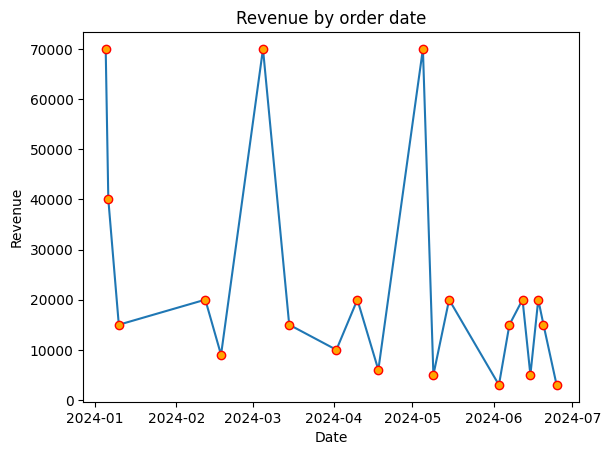

In [ ]:
# Revenue trend by order data
revenue=df.groupby("order_date")["revenue"].sum()
revenue=pd.DataFrame(revenue).reset_index()
plt.plot(revenue["order_date"],revenue["revenue"],marker="o",mfc="orange",mec="red")
plt.title("Revenue by order date")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.show()

**The revenue is very less in the last two months(mid may,june,july)**

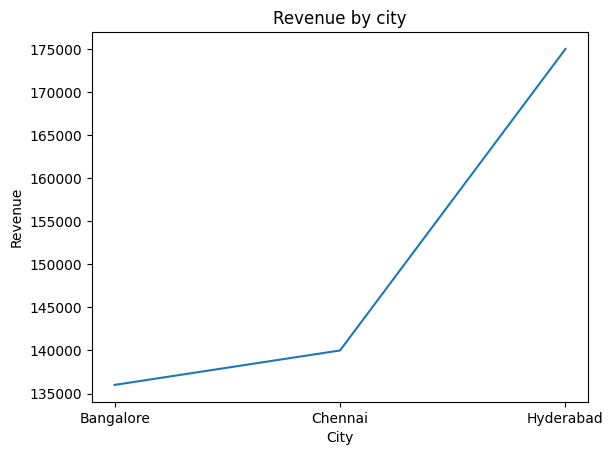

In [ ]:
#revenue trend by city
revenue_city=df.groupby("city")["revenue"].sum()
revenue_city=pd.DataFrame(revenue_city).reset_index()
plt.plot(revenue_city["city"],revenue_city["revenue"])
plt.title("Revenue by city")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.show()

**Revenue is dropping in Banglore**

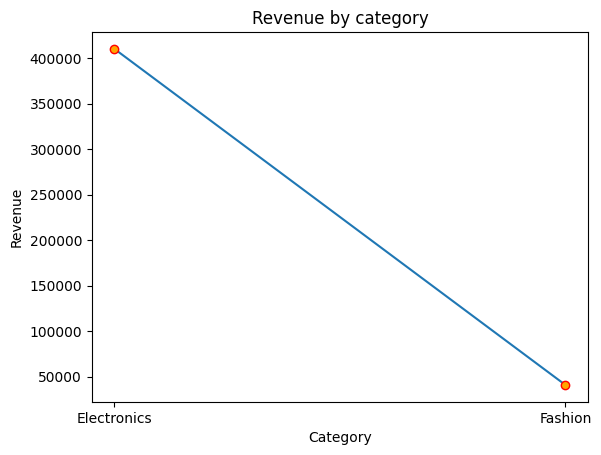

In [ ]:
#Revenue trend by category
revenue_category=df.groupby("category")["revenue"].sum()
revenue_category=pd.DataFrame(revenue_category).reset_index()
plt.plot(revenue_category["category"],revenue_category["revenue"],marker="o",mfc="orange",mec="red")
plt.title("Revenue by category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.show()

**In fashion category revenue got dropped**

In [ ]:
# count customers based on order id(count of orders per customer)
customer_count=df.groupby("customer_id")["order_id"].count()
customer_count

,order_id
customer_id,
101,3
102,2
103,2
104,2
105,1
106,1
107,1
108,1
109,1


**Most of the customers are ordering less**

Text(0, 0.5, 'Revenue')

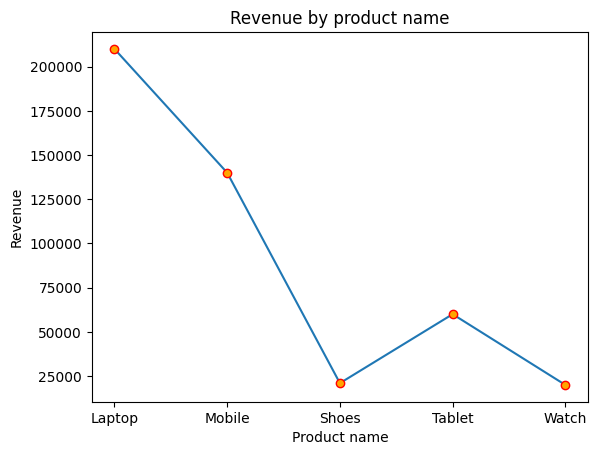

In [ ]:
#revenue trend by product name
revenue_product=df.groupby("product_name")["revenue"].sum()
revenue_product=pd.DataFrame(revenue_product).reset_index()
plt.plot(revenue_product["product_name"],revenue_product["revenue"],marker="o",mfc="orange",mec="red")
plt.title("Revenue by product name")
plt.xlabel("Product name")
plt.ylabel("Revenue")

**Revenue is very less for shoes and watch**

# Insights:
1) Revenue gor dropped in last two months(jun,july)
2) Banglore contributed more in revenue drop
3) Fashion category recorder less revenue
4) Repeated customers ordered less
5) shoes and watch sales declined significantly
# Recommendations:
1) Marketing should be done in Banglore.
2) Provide discounts for shoe and watch
3) coupons,discounts,loyalty programs